In [2]:
# ================================
# Clustering Turbo-Estável
# - Sweep rápido com amostragem estratificada
# - Shortlist de Ks (CH/DBI/Knee) + Silhouette médio (3 seeds) só nos candidatos
# - Regra de parcimônia (one-standard-error + Δ<=0.01)
# - Fit final no full + métricas + plots + perfis e export
# ================================

# (Opcional) Limitar threads BLAS/OpenMP para evitar oversubscription.
# Descomente ANTES de importar numpy/sklearn para fixar performance.
# import os as _os
# _os.environ["OMP_NUM_THREADS"] = "4"
# _os.environ["OPENBLAS_NUM_THREADS"] = "4"
# _os.environ["MKL_NUM_THREADS"] = "4"

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)
from sklearn.metrics import adjusted_rand_score

# Knee (cotovelo) para inertia (se disponível)
try:
    from kneed import KneeLocator
    HAVE_KNEE = True
except Exception:
    HAVE_KNEE = False
    print("[WARN] 'kneed' not available; knee will be ignored.")

In [3]:
# -------------------------------
# 0) Config (EDITE AQUI)
# -------------------------------
csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"
out_dir  = os.path.dirname(csv_path)

# Faixa de K (varredura)
K_min, K_max          = 2, 8

# Tamanhos de amostra
sweep_target_n        = 100_000   # subset para treinar MBK no sweep (50k–100k geralmente é bom)
sil_subset_n          = 3_000     # silhouette do sweep (estratificado, dentro do subset)
sil_full_n            = 3_000     # silhouette final no full (estratificado)
pca_plot_samples      = 10_000    # pontos para o scatter de PCA
sil_plot_samples      = 2_000     # pontos para o gráfico de silhouette

# Execução/estabilidade
random_state          = 42
sweep_seeds_for_sil   = (42, 43, 44)  # seeds para média de silhouette nos candidatos
stability_runs        = 0             # 0 = pular; use 3 para rodar; (roda no subset estratificado)

# Política de parcimônia
sil_delta_min         = 0.01          # se Δ-médio <= 0.01, prefira K menor
one_sd_rule           = True          # aplica one-standard-error (menor K dentro de média_best - 1*sd_best)

# Extras
save_k_table_csv      = True
remap_clusters_by     = "usage_per_365"  # ou None
export_profiles       = True
make_corr_plot        = False
make_sil_plot         = True

In [4]:
# -------------------------------
# 1) Carrega CSV
# -------------------------------
t0 = time.perf_counter()
df = pd.read_csv(csv_path)

required = ["usage_total","age_days","since_update_days","usage_per_365","staleness_ratio"]
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Faltam colunas no CSV: {missing}")

print(f"[INFO] Dados carregados: rows={len(df):,}, cols={df.shape[1]} em {time.perf_counter()-t0:.1f}s")

# -------------------------------
# 2) Matriz do modelo
# -------------------------------
X = df[required].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Reduz skew nas colunas de uso (log1p)
for col in ["usage_total", "usage_per_365"]:
    X[col] = np.log1p(np.clip(X[col].values, 0, None))

# Padroniza
scaler = StandardScaler()
Xs = scaler.fit_transform(X).astype(np.float32, copy=False)

n, d = Xs.shape
print(f"[INFO] Matriz do modelo: rows={n:,}, dims={d}, mem≈{Xs.nbytes/1e6:.1f} MB")

# RNG
rng = np.random.default_rng(random_state)

[INFO] Dados carregados: rows=639,106, cols=10 em 1.3s
[INFO] Matriz do modelo: rows=639,106, dims=5, mem≈12.8 MB


In [5]:
# -------------------------------
# 2.1) Funções auxiliares (estratificação e amostras)
# -------------------------------
def build_bins_df(X_df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria DF com colunas para estratificação:
      - u_log: usage_total (já em log1p)
      - rec: since_update_days
      - bin_u, bin_rec: quantis (qcut) para estratificação 10x10
    """
    aux = pd.DataFrame({
        "u_log": X_df["usage_total"].values,        # já está em log1p
        "rec":   X_df["since_update_days"].values,
    })
    # Bins por quantis; duplicates='drop' evita erro em colunas com muitos empates
    aux["bin_u"]   = pd.qcut(aux["u_log"], q=10, duplicates="drop")
    aux["bin_rec"] = pd.qcut(aux["rec"],   q=10, duplicates="drop")
    aux["idx"] = np.arange(len(aux))
    return aux

def stratified_sample_indices(df_bins: pd.DataFrame, target_n: int, rng) -> np.ndarray:
    """
    Amostragem estratificada proporcional.
    - Garante pelo menos 1 por estrato não vazio.
    - Ajusta para atingir exatamente 'target_n' (downsample ou top-up aleatório).
    """
    take = []
    N = len(df_bins)
    # Grupos por estratos
    grp = df_bins.groupby(["bin_u", "bin_rec"], observed=True)["idx"]
    for _, idxs in grp:
        idxs = idxs.values
        if len(idxs) == 0:
            continue
        k = max(1, int(target_n * (len(idxs) / N)))
        k = min(k, len(idxs))
        take.extend(rng.choice(idxs, size=k, replace=False))
    take = np.array(take, dtype=int)

    # Ajuste ao tamanho desejado
    if len(take) > target_n:
        take = rng.choice(take, size=target_n, replace=False)
    elif len(take) < target_n:
        # completa com amostra simples do restante
        remaining = np.setdiff1d(df_bins["idx"].values, take, assume_unique=False)
        if len(remaining) > 0:
            extra_k = min(target_n - len(take), len(remaining))
            extra = rng.choice(remaining, size=extra_k, replace=False)
            take = np.concatenate([take, extra])

    return np.array(take, dtype=int)

def silhouette_on_sample(X_emb: np.ndarray, labels: np.ndarray) -> float:
    """Silhouette médio numa amostra (X_emb/labels já amostrados)."""
    if len(np.unique(labels)) <= 1:
        return np.nan
    return float(silhouette_score(X_emb, labels))

In [6]:
# -------------------------------
# 3) Sweep de K no SUBSET (estratificado)
# -------------------------------
t_sweep = time.perf_counter()

# Bins no full para sortear subset estratificado
bins_full = build_bins_df(X)

sweep_n  = min(sweep_target_n, n)
sweep_ix = stratified_sample_indices(bins_full, sweep_n, rng)
Xs_sweep = Xs[sweep_ix]
print(f"[INFO] Subset do sweep: {sweep_n:,} linhas (estratificado)")

# Amostra de silhouette DENTRO do subset (estratificado)
bins_sweep = build_bins_df(X.iloc[sweep_ix].reset_index(drop=True))  # já cria 'idx' local 0..len-1
sil_n      = min(sil_subset_n, sweep_n)
sil_loc_ix = stratified_sample_indices(bins_sweep, sil_n, rng)
X_sil_subset = Xs_sweep[sil_loc_ix]
print(f"[INFO] Amostra silhouette no subset: {sil_n:,} linhas (estratificado)")

Ks        = list(range(K_min, K_max + 1))
inertias  = []
dbiscores = []
chiscores = []

print(f"[INFO] Iniciando sweep de K={K_min}..{K_max} no subset...")
for k in Ks:
    t_k = time.perf_counter()
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init=1,            # rápido no sweep
        batch_size=8192,     # aumente se tiver CPU/RAM
        max_iter=80,         # suficiente para ranquear Ks
        random_state=random_state
    )
    lbl_sweep = mbk.fit_predict(Xs_sweep)
    inertias.append(float(mbk.inertia_))

    # Métricas baratas no mesmo subset (DBI/CH)
    dbi = float(davies_bouldin_score(Xs_sweep, lbl_sweep)) if len(np.unique(lbl_sweep)) > 1 else np.nan
    chi = float(calinski_harabasz_score(Xs_sweep, lbl_sweep)) if len(np.unique(lbl_sweep)) > 1 else np.nan
    dbiscores.append(dbi)
    chiscores.append(chi)

    print(f"  [K={k}] sweep em {time.perf_counter()-t_k:.1f}s | Inertia={inertias[-1]:.1f} | DBI={dbi:.4f} | CH={chi:.1f}")

# Knee (inertia) se disponível
if HAVE_KNEE:
    kneedle = KneeLocator(Ks, inertias, curve="convex", direction="decreasing")
    k_knee  = int(kneedle.knee) if kneedle.knee is not None else None
else:
    k_knee  = None

# Candidatos por métricas baratas
k_by_ch  = Ks[int(np.nanargmax(chiscores))]
k_by_dbi = Ks[int(np.nanargmin(dbiscores))]
candidates = set([k_by_ch, k_by_dbi])
if k_knee is not None:
    candidates.add(k_knee)
candidates = sorted(candidates)

# Silhouette médio em 3 seeds (apenas candidatos), sempre no MESMO subset/mesma amostra X_sil_subset
def mean_sil_on_subset(k: int, seeds=(42,43,44)) -> tuple[float, float]:
    vals = []
    for s in seeds:
        mbk = MiniBatchKMeans(
            n_clusters=k, n_init=1, batch_size=8192, max_iter=100, random_state=s
        )
        lbl_sub = mbk.fit_predict(Xs_sweep)
        # usa os rótulos da amostra local (sil_loc_ix)
        vals.append(silhouette_on_sample(X_sil_subset, lbl_sub[sil_loc_ix]))
    return float(np.nanmean(vals)), float(np.nanstd(vals))

sil_stats = {}
for k in candidates:
    m, sd = mean_sil_on_subset(k, seeds=sweep_seeds_for_sil)
    sil_stats[k] = (m, sd)

# Regra de parcimônia (one-SE + Δ<=0.01)
best_k_by_mean = max(sil_stats, key=lambda kk: sil_stats[kk][0])
best_mean, best_sd = sil_stats[best_k_by_mean]
threshold = best_mean
if one_sd_rule:
    threshold = min(threshold, best_mean - best_sd)
threshold = min(threshold, best_mean - sil_delta_min)

parsimonious = [k for k,(m,_) in sil_stats.items() if m >= threshold]
best_k = min(parsimonious) if len(parsimonious) > 0 else best_k_by_mean

# Tabela-resumo da varredura
k_table = pd.DataFrame({
    "K": Ks,
    "Inertia (subset)": inertias,
    "DBI (↓, subset)": dbiscores,
    "CH (↑, subset)": chiscores
})

print("\n== Resumo do sweep de K (subset) ==")
print(k_table.round(4).to_string(index=False))

if save_k_table_csv:
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    k_table_csv = os.path.join(out_dir, "k_sweep_summary.csv")
    k_table.to_csv(k_table_csv, index=False, encoding="utf-8")
    print(f"[INFO] Tabela do sweep salva em: {k_table_csv}")

print(f"\nKnee (inertia no subset): {k_knee}")
print(f"Melhor por CH:            {k_by_ch}")
print(f"Melhor por DBI:           {k_by_dbi}")
print(f"Candidatos avaliados:     {candidates}")
print(f"Silhouette médio (3 seeds) nos candidatos: { {k: (round(sil_stats[k][0],4), round(sil_stats[k][1],4)) for k in sil_stats} }")
print(f"[Política] best_mean={best_mean:.4f}, sd={best_sd:.4f}, threshold={threshold:.4f} -> K escolhido={best_k}")
print(f"[INFO] Sweep concluído em {time.perf_counter()-t_sweep:.1f}s")

[INFO] Subset do sweep: 100,000 linhas (estratificado)
[INFO] Amostra silhouette no subset: 3,000 linhas (estratificado)
[INFO] Iniciando sweep de K=2..8 no subset...
  [K=2] sweep em 2.9s | Inertia=312219.8 | DBI=1.1647 | CH=60303.3
  [K=3] sweep em 0.1s | Inertia=231250.7 | DBI=1.0175 | CH=58132.5
  [K=4] sweep em 0.1s | Inertia=193865.7 | DBI=1.0833 | CH=52912.0
  [K=5] sweep em 0.2s | Inertia=138022.9 | DBI=0.8574 | CH=66657.9
  [K=6] sweep em 0.2s | Inertia=112271.1 | DBI=0.8411 | CH=69196.8
  [K=7] sweep em 0.2s | Inertia=93534.2 | DBI=0.8499 | CH=72742.8
  [K=8] sweep em 0.2s | Inertia=81561.6 | DBI=0.8533 | CH=73301.9

== Resumo do sweep de K (subset) ==
 K  Inertia (subset)  DBI (↓, subset)  CH (↑, subset)
 2       312219.8125           1.1647      60303.2817
 3       231250.7188           1.0175      58132.5359
 4       193865.6875           1.0833      52911.9508
 5       138022.9219           0.8574      66657.9119
 6       112271.0781           0.8411      69196.7670
 7   

In [7]:
# -------------------------------
# 4) Fit final no FULL (preciso)
# -------------------------------
t_final = time.perf_counter()
# Use KMeans clássico com elkan e n_init maior para robustez
kmeans = KMeans(n_clusters=best_k, n_init=10, algorithm="elkan", random_state=random_state)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels
print(f"[INFO] Fit final no full em {time.perf_counter()-t_final:.1f}s")

# Métricas finais:
# - DBI/CH no full (baratos)
# - Silhouette em amostra estratificada do full (sil_full_n)
bins_full = build_bins_df(X)  # (re)usa para sample final
sil_full_ix = stratified_sample_indices(bins_full, min(sil_full_n, n), rng)
sil_full = silhouette_on_sample(Xs[sil_full_ix], labels[sil_full_ix])
dbi_full = float(davies_bouldin_score(Xs, labels)) if len(np.unique(labels)) > 1 else np.nan
chi_full = float(calinski_harabasz_score(Xs, labels)) if len(np.unique(labels)) > 1 else np.nan
print(f"\n[Metrics @ K={best_k}] Silhouette≈{sil_full:.3f} | DBI={dbi_full:.3f} | CH={chi_full:.1f}")

[INFO] Fit final no full em 6.1s

[Metrics @ K=5] Silhouette≈0.411 | DBI=0.797 | CH=457899.5


In [8]:
# -------------------------------
# 4.1) (Opcional) Estabilidade ARI no subset estratificado
# -------------------------------
def kmeans_stability_subset(X_sub, k, runs=3, seed=42):
    lbls = []
    for r in range(runs):
        km = KMeans(n_clusters=k, n_init=10, algorithm="elkan", random_state=seed+r)
        lbls.append(km.fit_predict(X_sub))
    pairs = [(i, j) for i in range(runs) for j in range(i+1, runs)]
    aris = [adjusted_rand_score(lbls[i], lbls[j]) for i, j in pairs]
    return float(np.mean(aris)), float(np.std(aris))

if stability_runs and stability_runs >= 2:
    ari_mean, ari_std = kmeans_stability_subset(Xs_sweep, best_k, runs=stability_runs, seed=random_state)
    print(f"Estabilidade @ K={best_k} (ARI no subset): mean={ari_mean:.3f} ± {ari_std:.3f}")


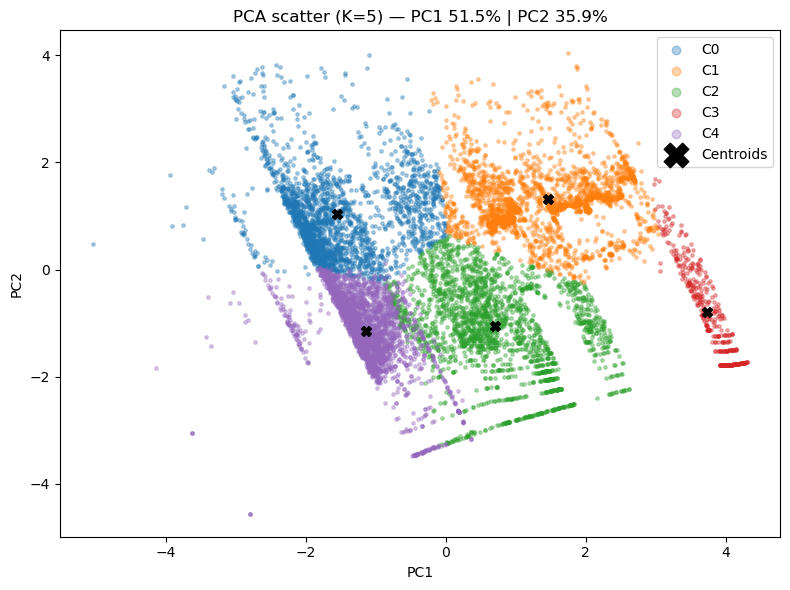

[INFO] Salvo: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\pca_scatter.png


In [14]:
# -------------------------------
# 5) PCA para visualização (2D)
# -------------------------------
pca = PCA(n_components=2, random_state=random_state)
XY = pca.fit_transform(Xs)
df["pca_x"] = XY[:, 0]
df["pca_y"] = XY[:, 1]
evr = pca.explained_variance_ratio_

# PCA scatter (amostrado) com centróides
plot_n    = min(pca_plot_samples, n)
plot_idx  = rng.choice(n, size=plot_n, replace=False)
XYp, lblp = XY[plot_idx], labels[plot_idx]
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
for c in np.unique(lblp):
    m = (lblp == c)
    plt.scatter(XYp[m, 0], XYp[m, 1], s=6, alpha=0.35, label=f"C{c}")
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", s=50, marker="X", label="Centroids")
plt.title(f"PCA scatter (K={best_k}) — PC1 {evr[0]*100:.1f}% | PC2 {evr[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(frameon=True, markerscale=2.5)
plt.tight_layout()
pca_png = os.path.join(out_dir, "pca_scatter.png")
plt.savefig(pca_png, dpi=150)
plt.show()
print(f"[INFO] Salvo: {pca_png}")

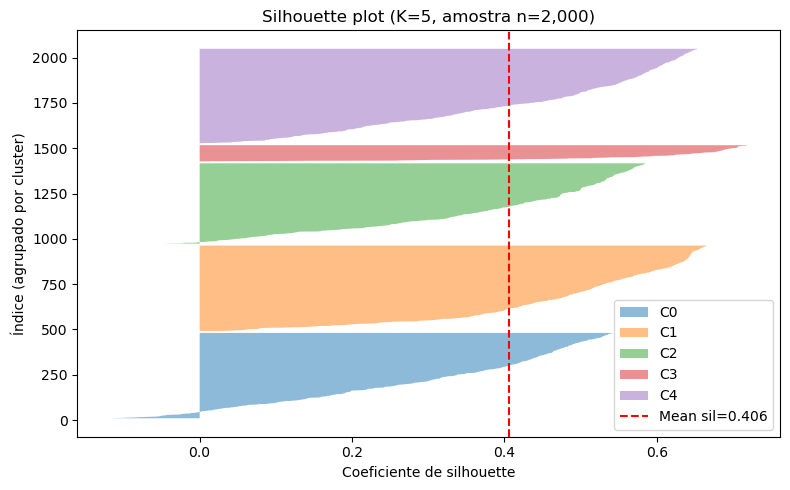

[INFO] Salvo: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\silhouette_plot.png


In [15]:
# -------------------------------
# 6) Silhouette plot (amostra pequena, estratificada)
# -------------------------------
if make_sil_plot:
    sp_n = min(sil_plot_samples, n)
    sp_ix = stratified_sample_indices(bins_full, sp_n, rng)
    Xs_sp, lbl_sp = Xs[sp_ix], labels[sp_ix]

    if len(np.unique(lbl_sp)) > 1:
        sil_vals = silhouette_samples(Xs_sp, lbl_sp)

        y_lower = 10
        plt.figure(figsize=(8, 5))
        for c in sorted(np.unique(lbl_sp)):
            c_sil  = np.sort(sil_vals[lbl_sp == c])
            size_c = c_sil.shape[0]
            y_upper = y_lower + size_c
            plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.5, label=f"C{c}")
            y_lower = y_upper + 10

        mean_sil = float(np.mean(sil_vals))
        plt.axvline(mean_sil, color="red", ls="--", label=f"Mean sil={mean_sil:.3f}")
        plt.xlabel("Coeficiente de silhouette"); plt.ylabel("Índice (agrupado por cluster)")
        plt.title(f"Silhouette plot (K={best_k}, amostra n={len(sil_vals):,})")
        plt.legend(frameon=True)
        plt.tight_layout()
        sil_png = os.path.join(out_dir, "silhouette_plot.png")
        plt.savefig(sil_png, dpi=150)
        plt.show()
        print(f"[INFO] Salvo: {sil_png}")
    else:
        print("[INFO] Silhouette plot pulado (apenas um cluster na amostra).")

[WARN] 'kneed' não disponível; knee será ignorado.
[INFO] Dados carregados: rows=639,106, cols=10 em 1.0s
[INFO] Matriz do modelo: rows=639,106, dims=5, mem≈12.8 MB
[INFO] Subset do sweep: 100,000 linhas (estratificado)
[INFO] Amostra silhouette no subset: 3,000 linhas (estratificado)
[INFO] Iniciando sweep de K=2..8 no subset...
  [K=2] sweep em 3.1s | Inertia=312219.8 | DBI=1.1647 | CH=60303.8
  [K=3] sweep em 0.1s | Inertia=231250.7 | DBI=1.0175 | CH=58132.0
  [K=4] sweep em 0.1s | Inertia=193865.7 | DBI=1.0833 | CH=52910.1
  [K=5] sweep em 0.2s | Inertia=138022.9 | DBI=0.8574 | CH=66656.3
  [K=6] sweep em 0.2s | Inertia=112271.1 | DBI=0.8411 | CH=69195.8
  [K=7] sweep em 0.1s | Inertia=93534.2 | DBI=0.8499 | CH=72742.0
  [K=8] sweep em 0.1s | Inertia=81561.6 | DBI=0.8533 | CH=73301.4

== Resumo do sweep de K (subset) ==
 K  Inertia (subset)  DBI (↓, subset)  CH (↑, subset)
 2       312219.8125           1.1647      60303.8477
 3       231250.7188           1.0175      58132.0312
 4

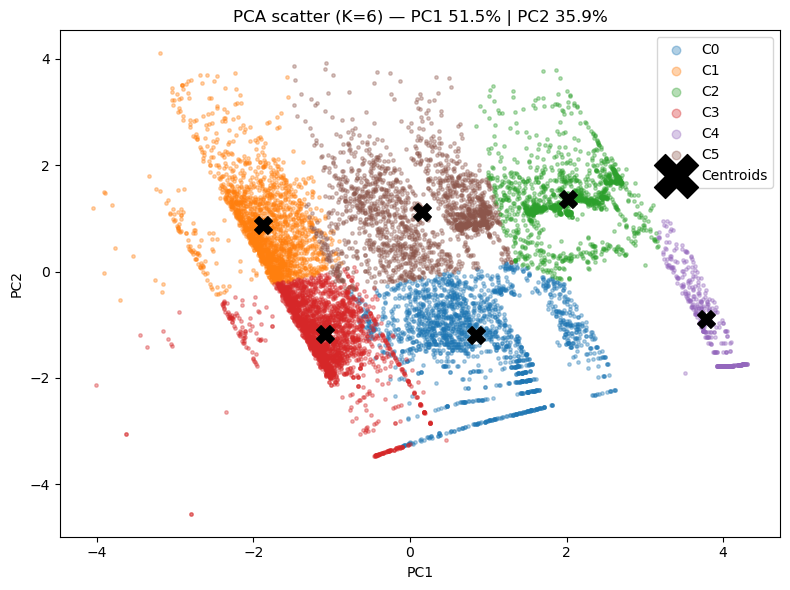

[INFO] Salvo: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\pca_scatter.png


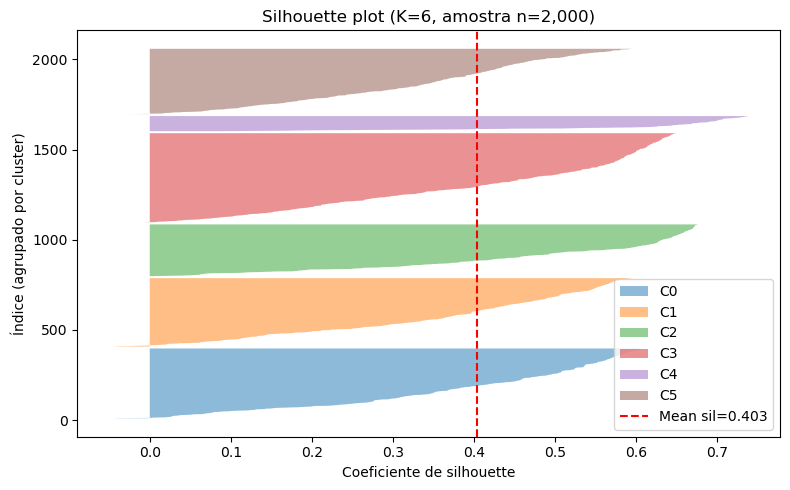

[INFO] Salvo: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\silhouette_plot.png
[INFO] Dataset com clusters exportado: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_results.csv

== Tamanho dos clusters ==
 cluster
0    124748
1    122302
2     91030
3    159966
4     26052
5    115008
Name: count, dtype: int64

== Perfil (médias das features) ==
          usage_total  age_days  since_update_days  usage_per_365  \
cluster                                                            
0              24.52    823.10             814.70          14.17   
1            2226.52    238.48             115.10        4716.52   
2             999.14   2206.08            2173.73         163.07   
3              42.68    294.11             131.78          72.08   
4              23.24   3435.14            2678.14           2.44   
5            1576.40    935.42             929.34         706.62   

         staleness_ratio  
cluster             

In [2]:
# -------------------------------
# 7) Export para Power BI
# -------------------------------
out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[INFO] Dataset com clusters exportado: {out_csv}")

# -------------------------------
# 8) Perfis rápidos e ricos
# -------------------------------
sizes = df["cluster"].value_counts().sort_index()
profile_mean = df.groupby("cluster")[required].mean().round(2)
print("\n== Tamanho dos clusters ==\n", sizes)
print("\n== Perfil (médias das features) ==\n", profile_mean)

def cluster_profile(df_src, by="cluster", cols=None):
    if cols is None:
        cols = required
    g = df_src.groupby(by)[cols]
    summary = g.agg(["mean", "median", "std"]).round(2)
    q = g.quantile([0.25, 0.75]).unstack().rename(columns={0.25: "q25", 0.75: "q75"}).round(2)
    prof = pd.concat([summary, q], axis=1)
    return prof

profile_rich = cluster_profile(df, by="cluster", cols=required)
print("\n== Perfil rico (mean/median/std + q25/q75) ==\n", profile_rich)

if export_profiles:
    prof_csv = os.path.join(out_dir, "cluster_profile_rich.csv")
    profile_rich.to_csv(prof_csv, encoding="utf-8")
    print(f"[INFO] Perfil do cluster salvo: {prof_csv}")

# (Opcional) IDs estáveis por 'usage_per_365'
if remap_clusters_by and remap_clusters_by in required:
    order = df.groupby("cluster")[remap_clusters_by].mean().sort_values().index
    map_id = {old: new for new, old in enumerate(order)}
    df["cluster_ord"] = df["cluster"].map(map_id)
    out_csv_ord = os.path.splitext(csv_path)[0] + "_results_ord.csv"
    df.to_csv(out_csv_ord, index=False, encoding="utf-8")
    print(f"[INFO] Exportado (com cluster_ord): {out_csv_ord}")

# (Opcional) Heatmap de correlação
if make_corr_plot:
    try:
        import seaborn as sns
        corr = df[required].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title("Correlação (features originais)")
        plt.tight_layout()
        corr_png = os.path.join(out_dir, "features_correlation.png")
        plt.savefig(corr_png, dpi=150)
        plt.show()
        print(f"[INFO] Salvo: {corr_png}")
    except Exception as e:
        print(f"[WARN] Heatmap de correlação pulado: {e}")